In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Vistazo a los datos

In [ ]:
df = pd.read_csv("../data/raw/Bank-Customer-Churn.csv")

In [ ]:
# Lectura basica de como se vé el dataset
print(df.shape) # (10000 rows, 18 col)
print(df.info())
df.head()

(10000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64 

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [18]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [ ]:
# el dataset viene limpio gracias a Dios
df.isnull().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

## Analizamos el target Exited

In [ ]:
print(df["Exited"].value_counts())
df["Exited"].value_counts(normalize=True) * 100
# 0 -> se quedan
# 1 -> se van

Exited
0    7962
1    2038
Name: count, dtype: int64


Exited
0    79.62
1    20.38
Name: proportion, dtype: float64

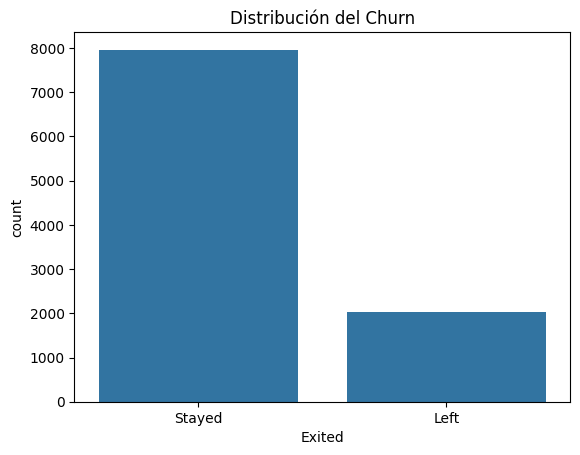

In [31]:
sns.countplot(data=df, x="Exited")
plt.xticks(
    [0, 1],
    ["Stayed", "Left"]
)
plt.title("Distribución del Churn")
plt.show()

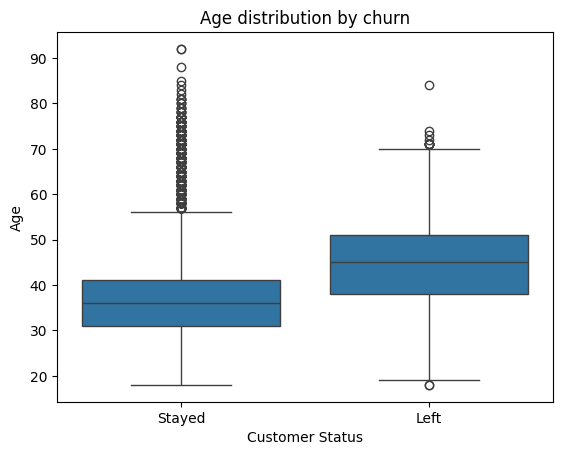

In [ ]:
sns.boxplot(
    data=df,
    x="Exited",
    y="Age"
)
# lo cambiaré en el dataset para que sea menos lío
plt.xticks(
    [0, 1],
    ["Stayed", "Left"]
)
plt.xlabel("Customer Status")
plt.ylabel("Age")

plt.title("Age distribution by churn")

plt.show()

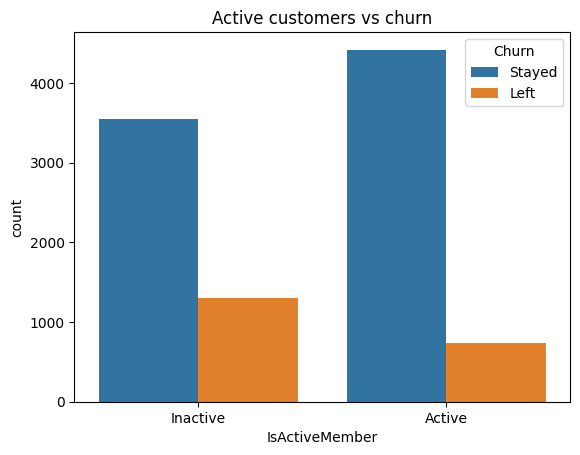

In [29]:
sns.countplot(
    data=df,
    x="IsActiveMember",
    hue="Exited"
)

plt.xticks([0, 1], ["Inactive", "Active"])

plt.legend(
    title="Churn",
    labels=["Stayed", "Left"]
)

plt.title("Active customers vs churn")

plt.show()

## Principales observaciones iniciales

Aproximadamente el 20% de los clientes del dataset abandonaron el banco, mientras que cerca del 80% permanecieron. Esto indica un cierto desbalance en la variable objetivo, algo que habrá que tener en cuenta más adelante durante el entrenamiento de modelos.

En términos absolutos:
- ~8000 clientes permanecieron en el banco
- ~2000 clientes abandonaron el servicio

### Edad y churn

El boxplot muestra que los clientes que abandonaron el banco suelen ser mayores que los que permanecieron.

La distribución de edades del grupo churn está desplazada hacia valores superiores, lo que sugiere que la edad podría ser una variable importante para predecir el abandono.

### Clientes activos y churn

A primera vista podría parecer que los clientes activos abandonan más el banco, pero esto se debe a que existen más clientes activos en el dataset.

Analizando las proporciones, los clientes inactivos presentan una tasa de abandono considerablemente mayor.

### Matriz de correlación

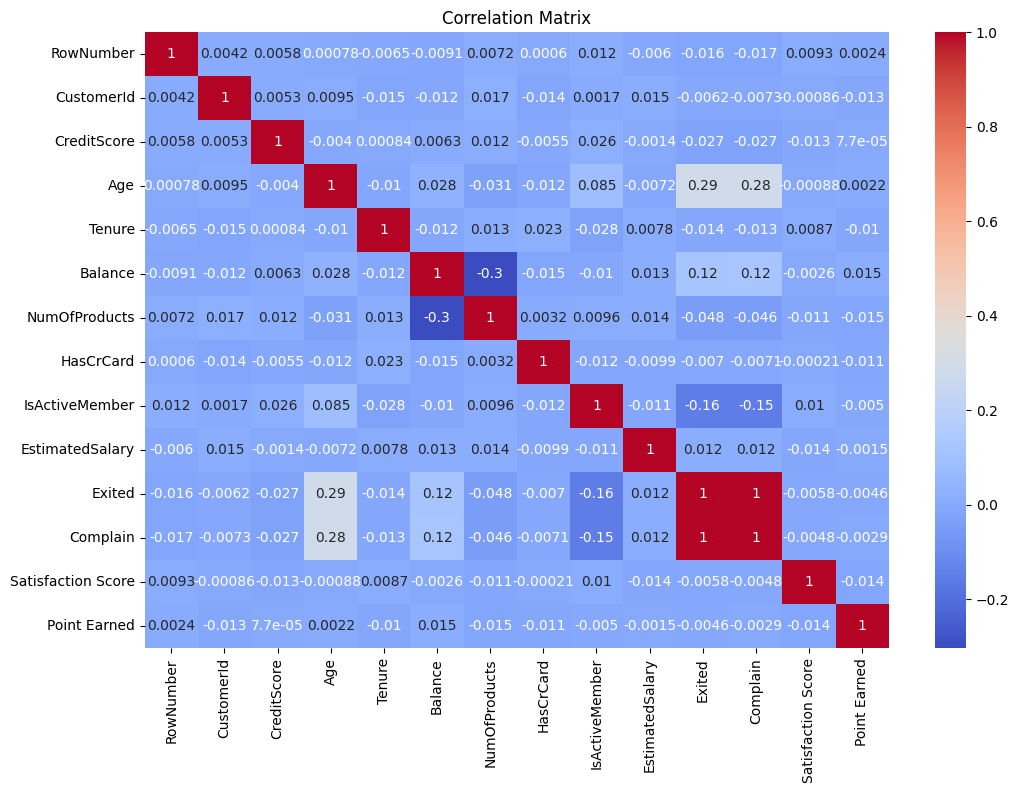

In [32]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

#### Posible data leakage

La variable `Complain` presenta una correlación prácticamente perfecta con la variable objetivo (`Exited`).

Esto podría indicar data leakage, ya que la información contenida en esta variable parece revelar directamente si el cliente abandonó el banco.

Por este motivo, será necesario estudiar si conviene eliminar esta variable durante la fase de modelado para evitar resultados artificialmente altos.

## Distribuciones numéricas

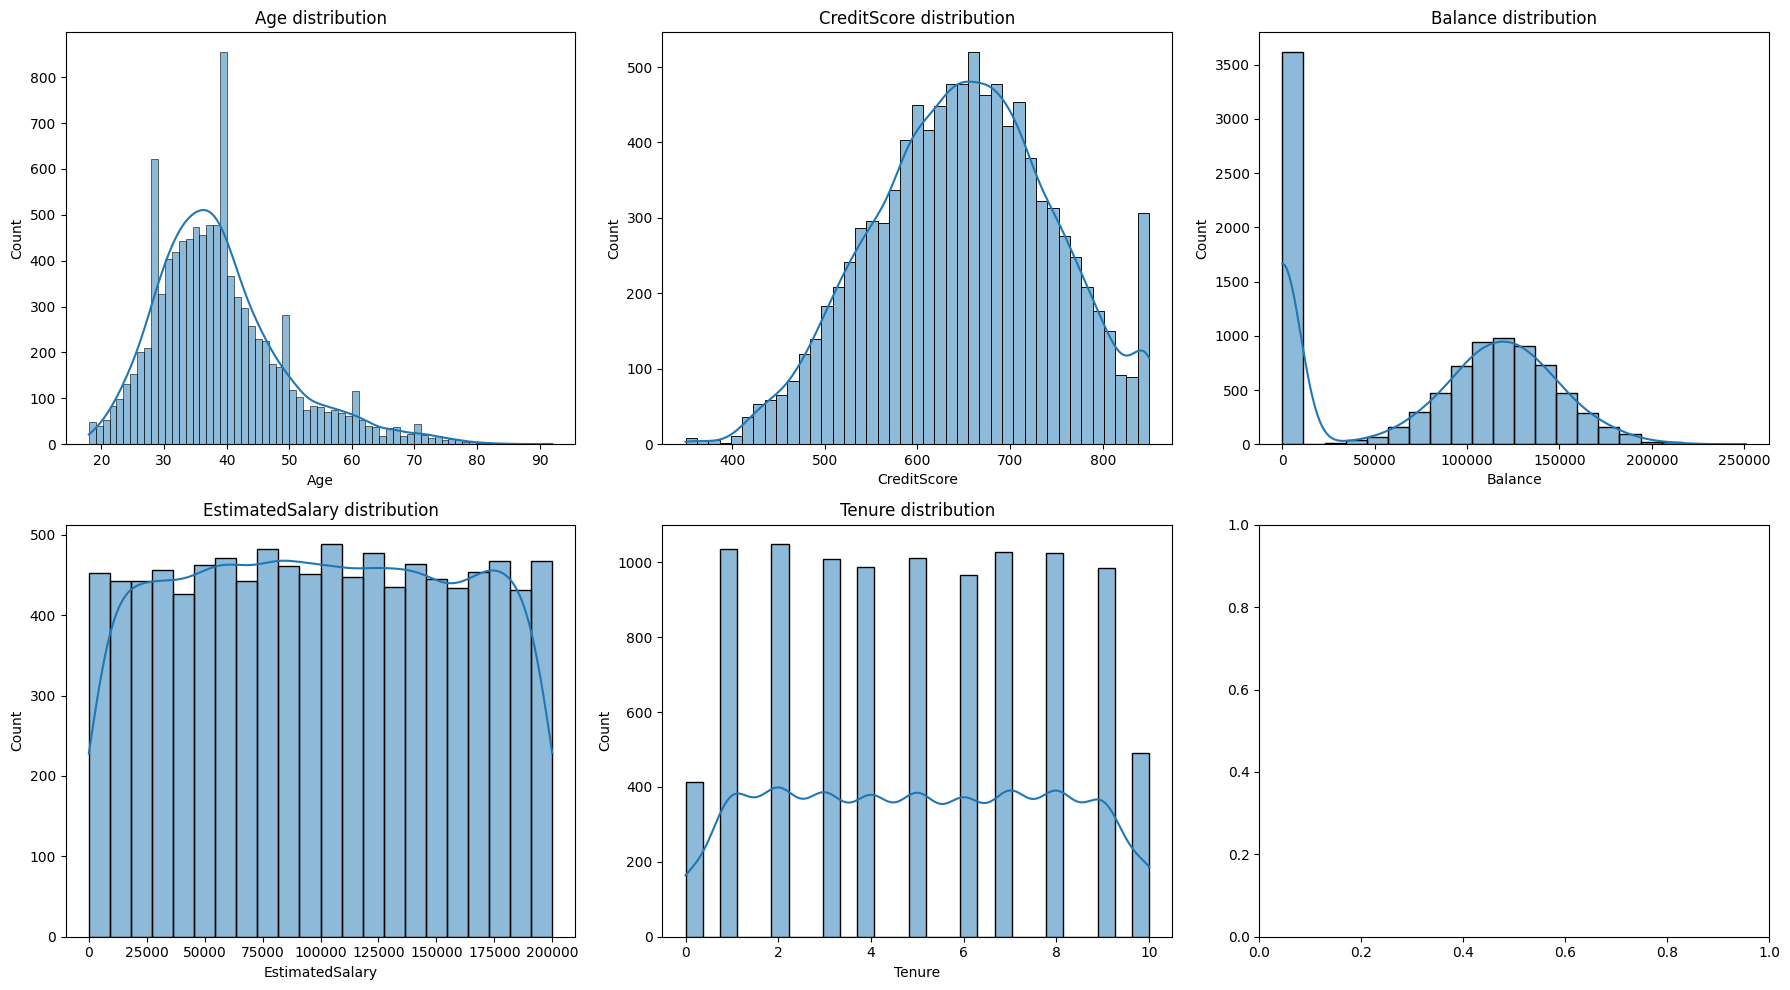

In [33]:
numerical_cols = [
    "Age",
    "CreditScore",
    "Balance",
    "EstimatedSalary",
    "Tenure"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} distribution")

plt.tight_layout()
plt.show()

## Boxplot vs Churn

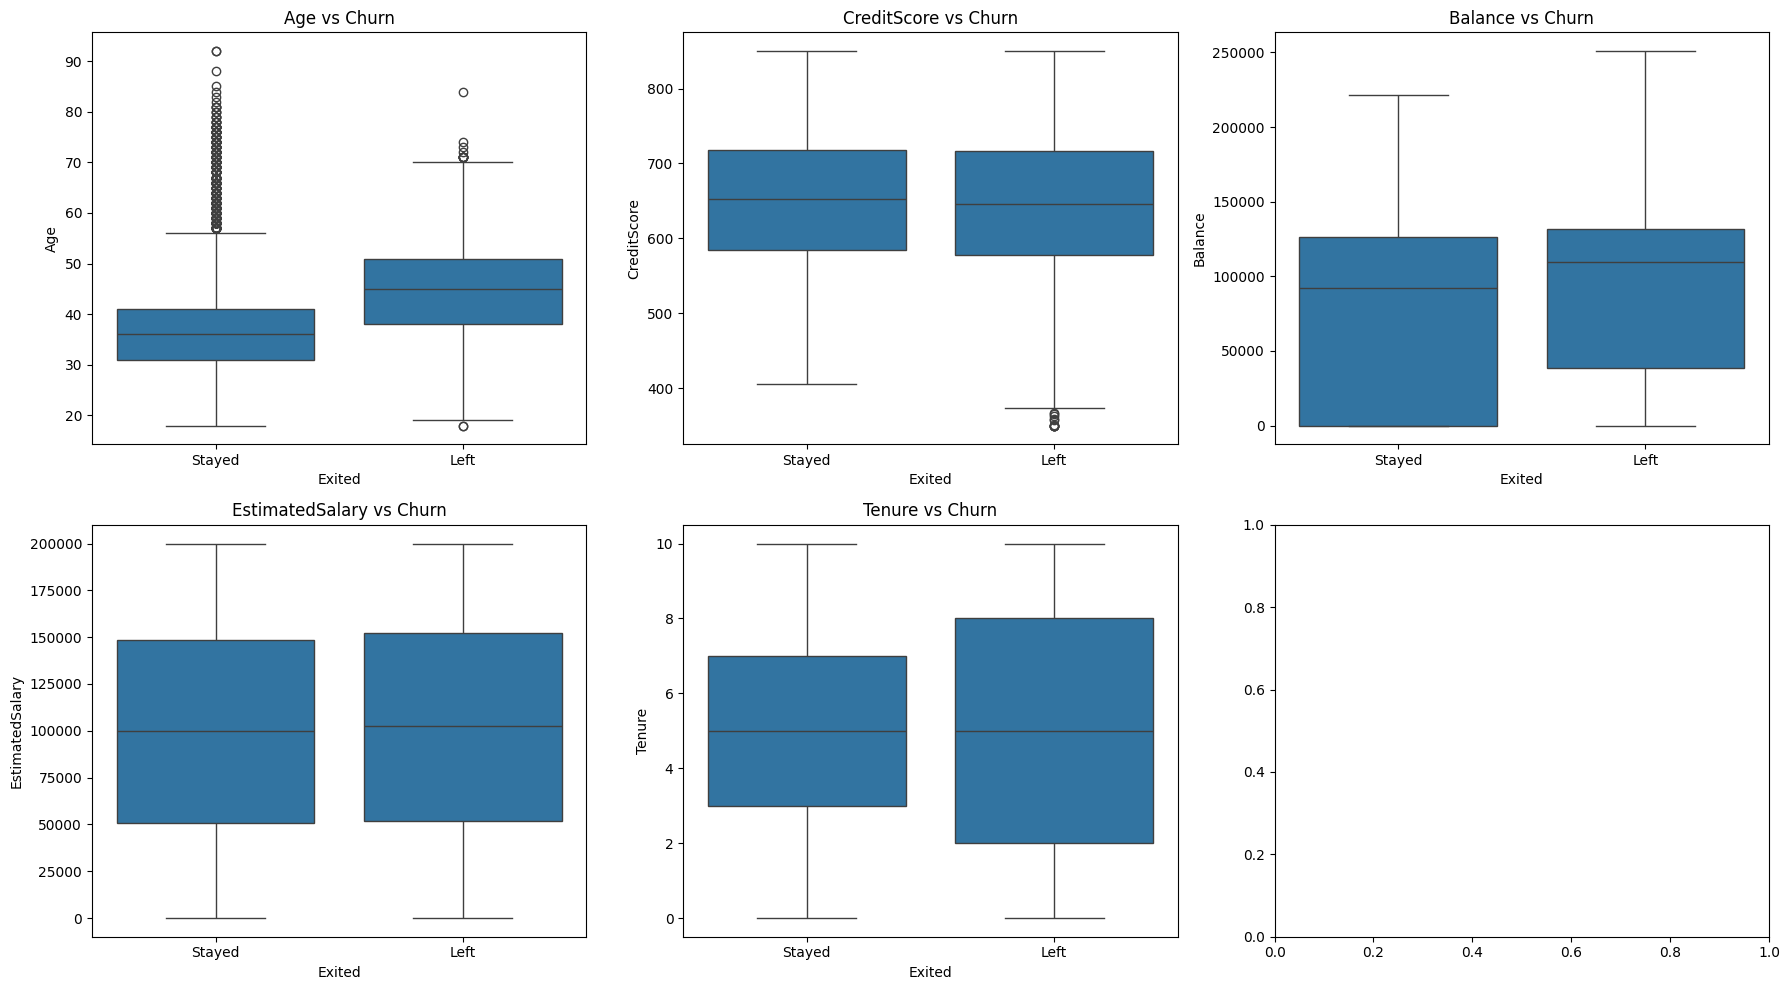

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.boxplot(
        data=df,
        x="Exited",
        y=col,
        ax=axes[i]
    )

    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Stayed", "Left"])

    axes[i].set_title(f"{col} vs Churn")

plt.tight_layout()
plt.show()

## Variables Categóricas

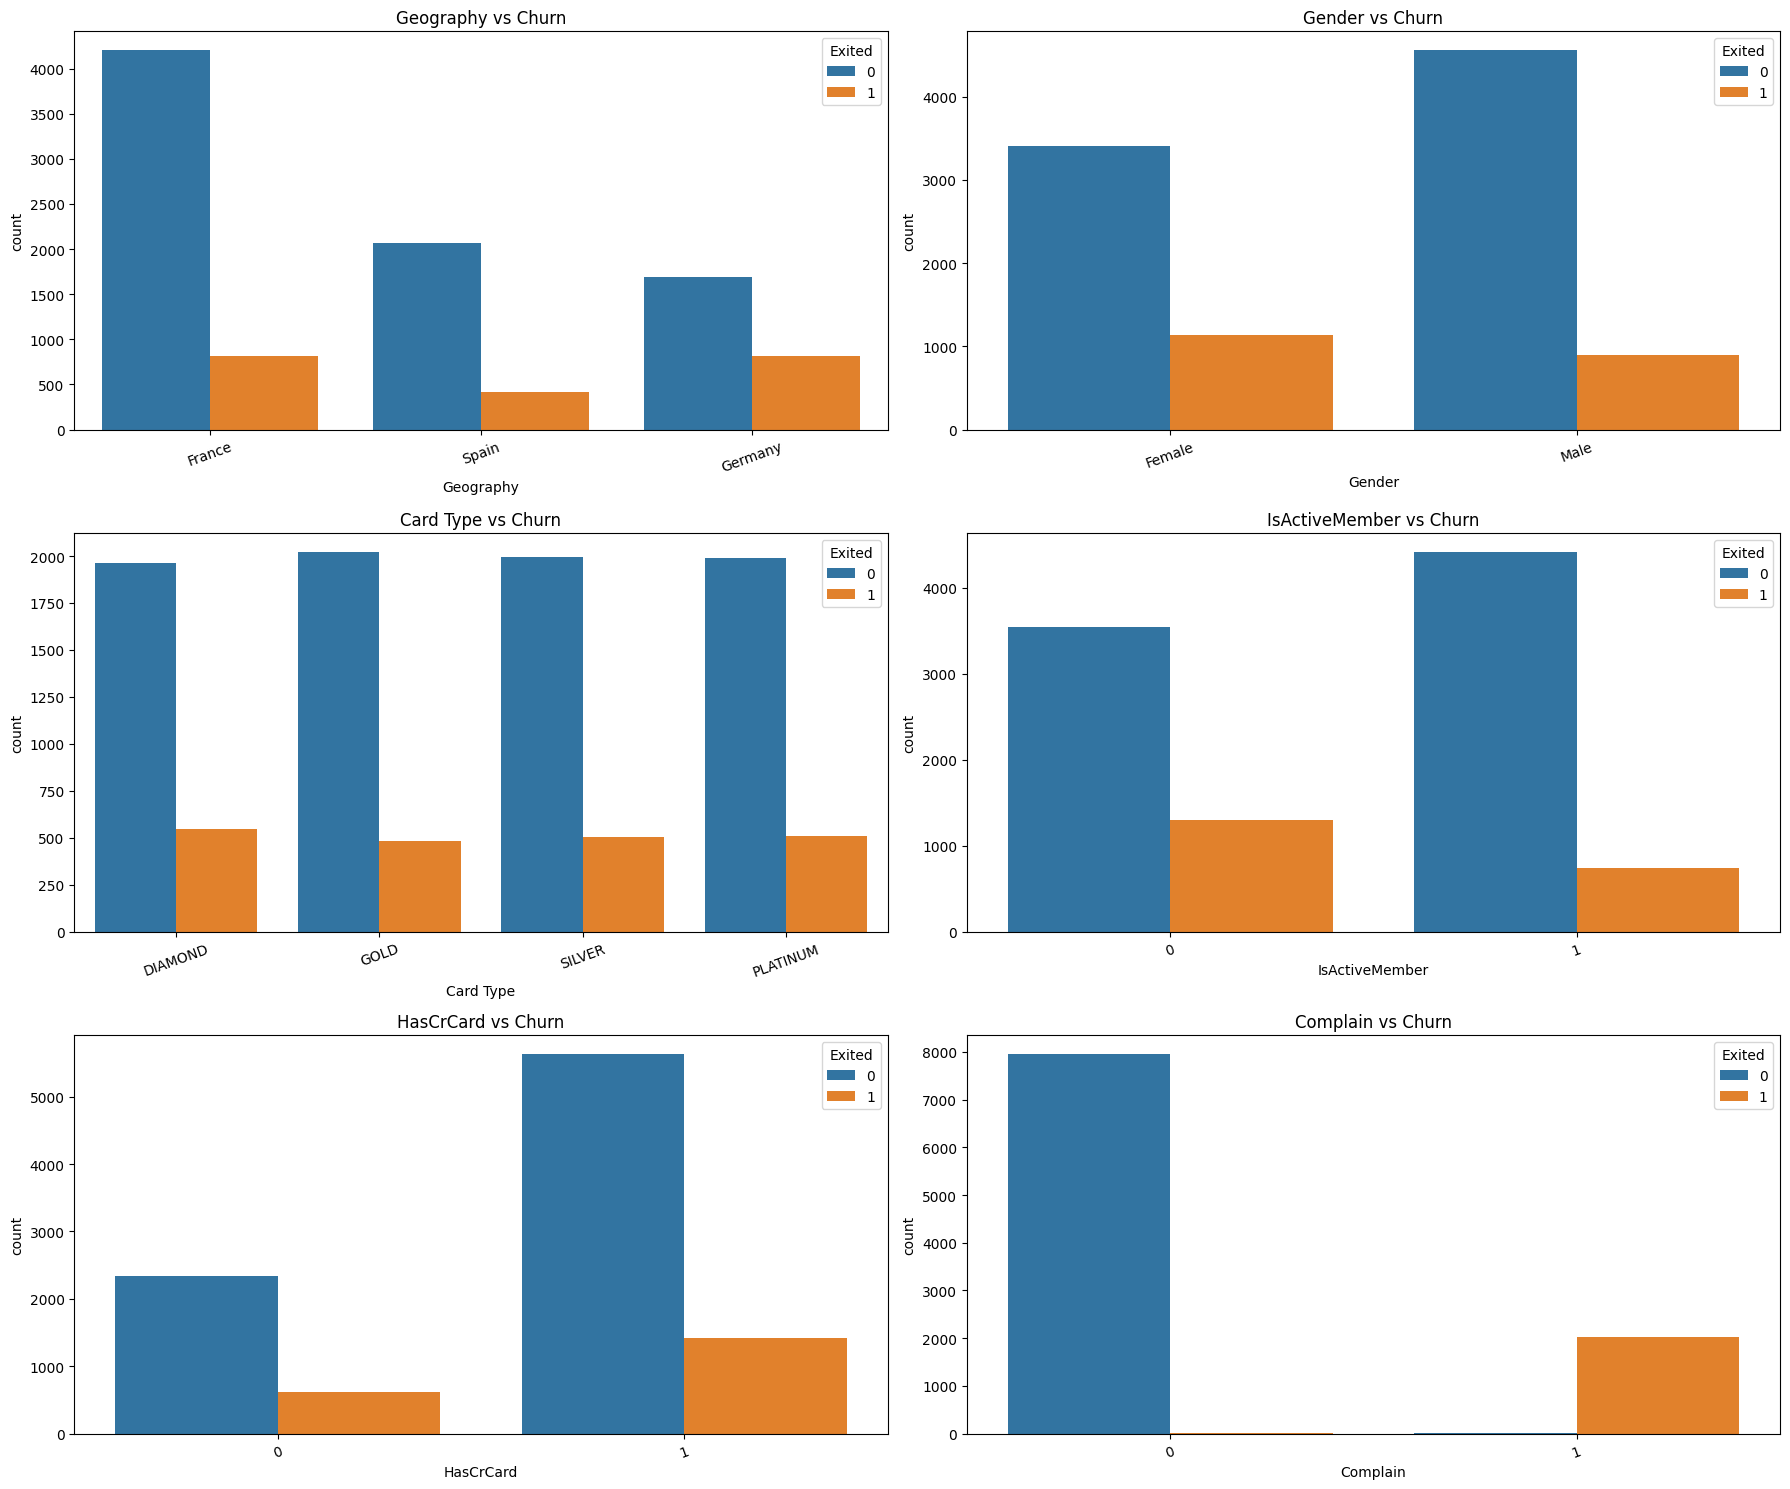

In [35]:
categorical_cols = [
    "Geography",
    "Gender",
    "Card Type",
    "IsActiveMember",
    "HasCrCard",
    "Complain"
]

fig, axes = plt.subplots(3, 2, figsize=(18, 15))

axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    sns.countplot(
        data=df,
        x=col,
        hue="Exited",
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs Churn")
    axes[i].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()